<a href="https://colab.research.google.com/github/DavidAromose/pneumonia-detection-transfer-learning/blob/main/Pneumonia_Detection_using_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pneumonia Detection using Transfer Learning

This project explores the impact of model complexity on pneumonia detection using chest X-ray images.

The following pretrained CNN models were evaluated:
- MobileNetV2
- ResNet50
- EfficientNetB0

The goal is to compare performance, generalisation, and robustness to class imbalance.


## 1. Setup and imports

In [4]:
# If a package is missing on Colab, uncomment:
# !pip install -q tensorflow scikit-learn matplotlib seaborn

import os, time, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_pre
from tensorflow.keras.applications.resnet50   import preprocess_input as resnet_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pre

from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             classification_report, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED); np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: []


## 2. Configuration
One place to control every experiment knob.

In [5]:
# --- Dataset location (Kaggle 'Chest X-Ray Images (Pneumonia)') ---
# After unzipping, you should have: <base>/train/{NORMAL,PNEUMONIA} and <base>/test/...
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/archive/chest_xray"   # <-- edit if needed
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.15

# Training schedule (two-phase). EarlyStopping usually stops well before the cap.
EPOCHS_HEAD = 25     # phase 1: frozen base, train new head
EPOCHS_FT   = 15     # phase 2: unfreeze top layers, fine-tune
LR_HEAD     = 1e-3
LR_FT       = 1e-5   # much smaller LR for fine-tuning
FT_UNFREEZE = 30     # how many of the top base layers to unfreeze

assert os.path.isdir(TRAIN_DIR), f"Not found: {TRAIN_DIR}"
print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes :", os.listdir(TEST_DIR))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train classes: ['NORMAL', 'PNEUMONIA']
Test classes : ['PNEUMONIA', 'NORMAL']


## 3. Data pipeline


In [6]:
PRE_FN = {
    "MobileNetV2":    mobilenet_pre,
    "ResNet50":       resnet_pre,
    "EfficientNetB0": effnet_pre,
}

# Augmentation layers (training only). Matches the paper: flip, small rotation, zoom.
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),   # ~10 degrees
    tf.keras.layers.RandomZoom(0.1),
], name="augment")

def make_datasets(preprocess_fn):
    # Build train/val/test tf.data pipelines for one model preprocessing
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, labels="inferred", label_mode="binary",
        image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT, subset="training", seed=SEED, shuffle=True)
    val_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, labels="inferred", label_mode="binary",
        image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT, subset="validation", seed=SEED, shuffle=False)
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR, labels="inferred", label_mode="binary",
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

    class_names = train_ds.class_names  # ['NORMAL','PNEUMONIA'] -> 0,1

    AUTOTUNE = tf.data.AUTOTUNE
    def prep(ds, training=False):
        if training:
            ds = ds.map(lambda x, y: (augment(x, training=True), y),
                        num_parallel_calls=AUTOTUNE)
        ds = ds.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=AUTOTUNE)
        return ds.prefetch(AUTOTUNE)

    return (prep(train_ds, True), prep(val_ds), prep(test_ds), class_names)

# Compute class weights once from the raw training directory (addresses imbalance).
def get_class_weights():
    counts = {}
    for i, cls in enumerate(sorted(os.listdir(TRAIN_DIR))):
        counts[i] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    total = sum(counts.values()); n = len(counts)
    weights = {i: total / (n * c) for i, c in counts.items()}
    print("Train counts:", counts, "-> class_weight:", weights)
    return weights

CLASS_WEIGHTS = get_class_weights()


Train counts: {0: 1341, 1: 3875} -> class_weight: {0: 1.9448173005219984, 1: 0.6730322580645162}


## 4. Model builder (two-phase capable)


In [7]:
def build_model(base_model_fn, input_shape=(224,224,3)):
    base = base_model_fn(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False                      # phase 1: frozen
    inp = Input(shape=input_shape)
    x = base(inp, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation="sigmoid")(x)
    model = Model(inp, out)
    return model, base

def compile_model(model, lr):
    model.compile(optimizer=Adam(lr), loss="binary_crossentropy",
                  metrics=["accuracy",
                           tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Recall(name="recall"),
                           tf.keras.metrics.Precision(name="precision")])


## 5. Efficiency metrics: parameters, FLOPs/MACs, latency


In [8]:
def get_flops(model):
    # Estimate FLOPs via the TF profiler; returns total float ops
    try:
        from tensorflow.python.framework.convert_to_constants import (
            convert_variables_to_constants_v2_as_graph)
        forward = tf.function(lambda x: model(x))
        concrete = forward.get_concrete_function(
            tf.TensorSpec([1] + list(model.inputs[0].shape[1:]), model.inputs[0].dtype))
        frozen, _ = convert_variables_to_constants_v2_as_graph(concrete)
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(
            graph=frozen.graph, run_meta=run_meta, cmd="op", options=opts)
        return flops.total_float_ops
    except Exception as e:
        print("FLOPs estimate unavailable:", e); return None

def measure_latency(model, n_warmup=5, n_runs=30):
    # Mean single-image inference latency in ms
    dummy = tf.random.normal([1, 224, 224, 3])
    for _ in range(n_warmup): _ = model(dummy, training=False)
    t0 = time.perf_counter()
    for _ in range(n_runs): _ = model(dummy, training=False)
    return (time.perf_counter() - t0) / n_runs * 1000.0


## 6. Train all three models (two-phase + class weights + early stopping)

In [9]:
BASE_FNS = {"MobileNetV2": MobileNetV2, "ResNet50": ResNet50, "EfficientNetB0": EfficientNetB0}

histories, trained = {}, {}

for name, fn in BASE_FNS.items():
    print("\n" + "="*72 + f"\nTRAINING {name}\n" + "="*72)
    train_ds, val_ds, test_ds, class_names = make_datasets(PRE_FN[name])

    model, base = build_model(fn)
    compile_model(model, LR_HEAD)

    cbs = [EarlyStopping(monitor="val_auc", mode="max", patience=5,
                         restore_best_weights=True),
           ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)]

    # Phase 1 - frozen base
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
                   class_weight=CLASS_WEIGHTS, callbacks=cbs, verbose=2)

    # Phase 2 - fine-tune top layers
    base.trainable = True
    for layer in base.layers[:-FT_UNFREEZE]:
        layer.trainable = False
    compile_model(model, LR_FT)
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT,
                   class_weight=CLASS_WEIGHTS, callbacks=cbs, verbose=2)

    histories[name] = (h1, h2)
    trained[name] = (model, test_ds, class_names)
    print(f"{name}: done. Total params = {model.count_params():,}")



TRAINING MobileNetV2
Found 5216 files belonging to 2 classes.
Using 4434 files for training.
Found 5216 files belonging to 2 classes.
Using 782 files for validation.
Found 624 files belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
139/139 - 918s - 7s/step - accuracy: 0.8972 - auc: 0.9655 - loss: 0.2367 - precision: 0.9660 - recall: 0.8925 - val_accuracy: 0.9463 - val_auc: 0.0000e+00 - val_loss: 0.1149 - val_precision: 1.0000 - val_recall: 0.9463 - learning_rate: 0.0010
Epoch 2/25
139/139 - 329s - 2s/step - accuracy: 0.9484 - auc: 0.9895 - loss: 0.1282 - precision: 0.9851 - recall: 0.9446 - val_accuracy: 0.9271 - val_auc: 0.0000e+00 - val_loss: 0.1657 - val_precision: 1.0000 - val_recall: 0.9271 - learning_rate: 0.0010
Epoch 3/25
139/139 - 325s - 2s/step - accuracy: 0.9565 - auc: 0.9925 - loss: 0.1075 - precision: 0.9877 - recall: 0.9531 - val_accuracy: 0.9297 - val_auc: 0.0000e+00 - val_loss: 0.1702 - val_precision: 1.0000 - val_recall: 0.9297 - lear

## 7. Evaluation: metrics, confusion matrices, ROC curves, efficiency, CIs

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


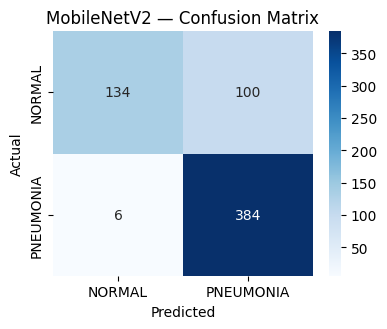

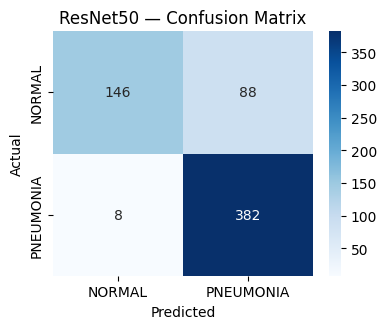

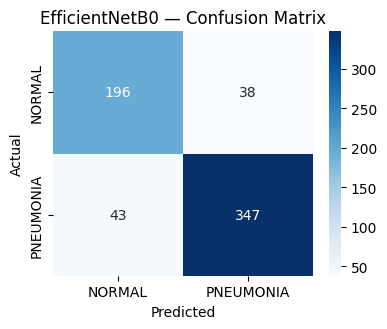

,Model,Params(M),GFLOPs,Latency(ms),Test Acc,Acc 95% CI,ROC-AUC,AUC 95% CI,Sensitivity,Specificity,Precision,F1
0,MobileNetV2,2.42,0.61,297.39,0.830,"[0.803, 0.861]",0.962,"[0.948, 0.975]",0.985,0.573,0.793,0.879
1,ResNet50,23.85,7.75,602.62,0.846,"[0.817, 0.873]",0.955,"[0.938, 0.970]",0.979,0.624,0.813,0.888
2,EfficientNetB0,4.21,0.80,495.62,0.870,"[0.843, 0.894]",0.937,"[0.918, 0.955]",0.890,0.838,0.901,0.895


In [10]:
def bootstrap_ci(y_true, y_score, y_pred, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed); n = len(y_true)
    accs, aucs = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        accs.append(accuracy_score(y_true[idx], y_pred[idx]))
        fpr, tpr, _ = roc_curve(y_true[idx], y_score[idx]); aucs.append(auc(fpr, tpr))
    pct = lambda a: (np.percentile(a, 2.5), np.percentile(a, 97.5))
    return pct(accs), pct(aucs)

rows, roc_data = [], {}

for name, (model, test_ds, class_names) in trained.items():
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).ravel().astype(int)
    y_score = model.predict(test_ds, verbose=0).ravel()
    y_pred = (y_score >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc  = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)               # pneumonia recall
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    prec = precision_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_score); roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

    (acc_lo, acc_hi), (auc_lo, auc_hi) = bootstrap_ci(y_true, y_score, y_pred)
    flops = get_flops(model); lat = measure_latency(model)

    rows.append({"Model": name, "Params(M)": round(model.count_params()/1e6, 2),
                 "GFLOPs": round(flops/1e9, 2) if flops else None,
                 "Latency(ms)": round(lat, 2),
                 "Test Acc": round(acc, 3), "Acc 95% CI": f"[{acc_lo:.3f}, {acc_hi:.3f}]",
                 "ROC-AUC": round(roc_auc, 3), "AUC 95% CI": f"[{auc_lo:.3f}, {auc_hi:.3f}]",
                 "Sensitivity": round(sens, 3), "Specificity": round(spec, 3),
                 "Precision": round(prec, 3), "F1": round(f1, 3)})

    # Confusion matrix plot
    plt.figure(figsize=(4, 3.4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.savefig(f"cm_{name}.png", dpi=200); plt.show()

results_df = pd.DataFrame(rows)
results_df.to_csv("results_summary.csv", index=False)
results_df


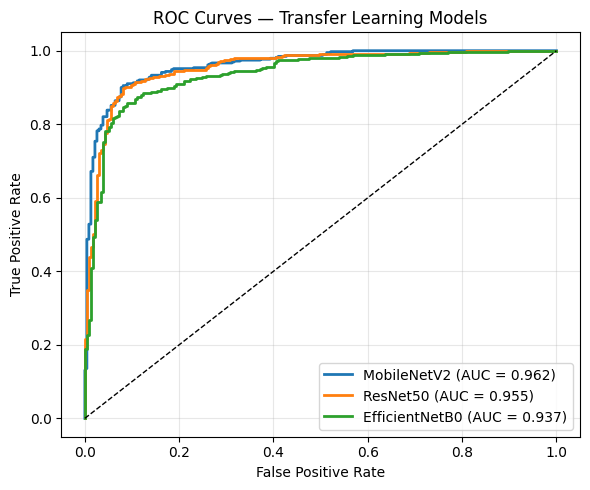

In [11]:
# Combined ROC curve (publication figure)
plt.figure(figsize=(6, 5))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Transfer Learning Models")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("roc_combined.png", dpi=200); plt.show()


## 8. Training curves (per model, both phases)

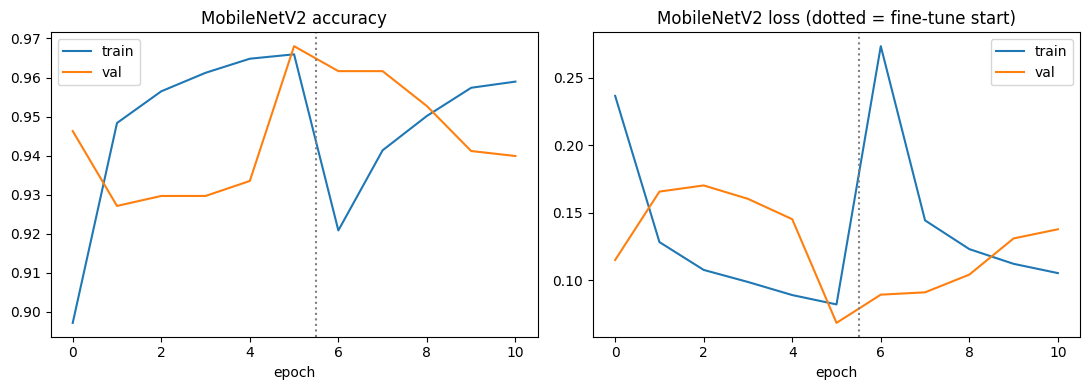

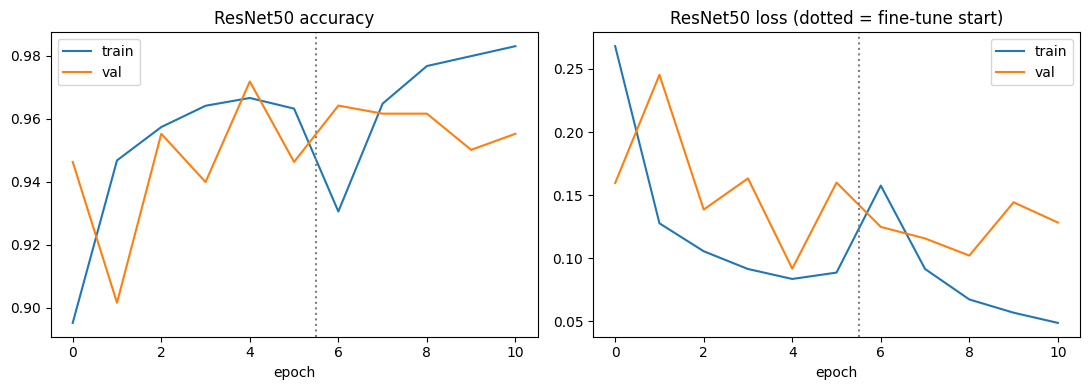

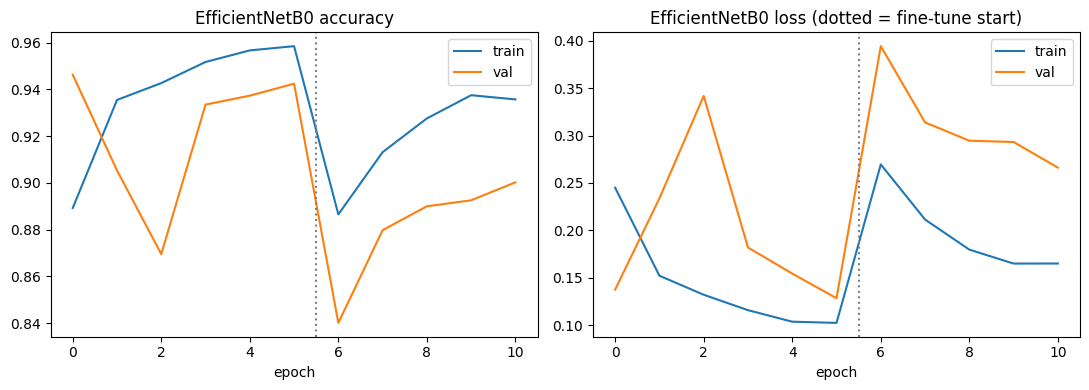

In [12]:
def plot_history(name, h1, h2):
    def cat(k):
        return h1.history.get(k, []) + h2.history.get(k, [])
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(cat("accuracy"), label="train"); ax[0].plot(cat("val_accuracy"), label="val")
    ax[0].axvline(len(h1.history["accuracy"]) - 0.5, ls=":", c="gray")
    ax[0].set_title(f"{name} accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(cat("loss"), label="train"); ax[1].plot(cat("val_loss"), label="val")
    ax[1].axvline(len(h1.history["loss"]) - 0.5, ls=":", c="gray")
    ax[1].set_title(f"{name} loss (dotted = fine-tune start)")
    ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.savefig(f"history_{name}.png", dpi=200); plt.show()

for name, (h1, h2) in histories.items():
    plot_history(name, h1, h2)
